## BANK LOAN ANALYSIS REPORT

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
import plotly.express as px

In [3]:
df = pd.read_excel(r"C:\Users\mayank raj\Downloads\financial_loan_data_excel.xlsx")

In [4]:
df.head()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2021-02-11,2021-09-13,2021-04-13,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,2021-01-01,2021-12-14,2021-01-15,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,2021-01-05,2021-12-12,2021-01-09,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,2021-02-25,2021-12-12,2021-03-12,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,2021-01-01,2021-12-14,2021-01-15,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


In [6]:
df.shape

(38576, 24)

In [7]:
df.info


<bound method DataFrame.info of             id address_state application_type emp_length  \
0      1077430            GA       INDIVIDUAL   < 1 year   
1      1072053            CA       INDIVIDUAL    9 years   
2      1069243            CA       INDIVIDUAL    4 years   
3      1041756            TX       INDIVIDUAL   < 1 year   
4      1068350            IL       INDIVIDUAL  10+ years   
...        ...           ...              ...        ...   
38571   803452            NJ       INDIVIDUAL   < 1 year   
38572   970377            NY       INDIVIDUAL    8 years   
38573   875376            CA       INDIVIDUAL    5 years   
38574   972997            NY       INDIVIDUAL    5 years   
38575   682952            NY       INDIVIDUAL    4 years   

                             emp_title grade home_ownership issue_date  \
0                                Ryder     C           RENT 2021-02-11   
1                       MKC Accounting     E           RENT 2021-01-01   
2                Chemat T

In [8]:
df.dtypes

id                                int64
address_state                    object
application_type                 object
emp_length                       object
emp_title                        object
grade                            object
home_ownership                   object
issue_date               datetime64[ns]
last_credit_pull_date    datetime64[ns]
last_payment_date        datetime64[ns]
loan_status                      object
next_payment_date        datetime64[ns]
member_id                         int64
purpose                          object
sub_grade                        object
term                             object
verification_status              object
annual_income                   float64
dti                             float64
installment                     float64
int_rate                        float64
loan_amount                       int64
total_acc                         int64
total_payment                     int64
dtype: object

In [9]:
df.describe()

,id,issue_date,last_credit_pull_date,last_payment_date,next_payment_date,member_id,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
count,3.857600e+04,38576,38576,38576,38576,3.857600e+04,3.857600e+04,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000
mean,6.810371e+05,2021-07-16 02:31:35.562007040,2021-06-08 13:36:34.193280512,2021-06-26 09:52:08.909166080,2021-07-26 20:42:20.605557760,8.476515e+05,6.964454e+04,0.133274,326.862965,0.120488,11296.066855,22.132544,12263.348533
min,5.473400e+04,2021-01-01 00:00:00,2021-01-08 00:00:00,2021-01-08 00:00:00,2021-02-08 00:00:00,7.069900e+04,4.000000e+03,0.000000,15.690000,0.054200,500.000000,2.000000,34.000000
25%,5.135170e+05,2021-04-11 00:00:00,2021-04-15 00:00:00,2021-03-16 00:00:00,2021-04-16 00:00:00,6.629788e+05,4.150000e+04,0.082100,168.450000,0.093200,5500.000000,14.000000,5633.000000
50%,6.627280e+05,2021-07-11 00:00:00,2021-05-16 00:00:00,2021-06-14 00:00:00,2021-07-14 00:00:00,8.473565e+05,6.000000e+04,0.134200,283.045000,0.118600,10000.000000,20.000000,10042.000000
75%,8.365060e+05,2021-10-11 00:00:00,2021-08-13 00:00:00,2021-09-15 00:00:00,2021-10-15 00:00:00,1.045652e+06,8.320050e+04,0.185900,434.442500,0.145900,15000.000000,29.000000,16658.000000
max,1.077501e+06,2021-12-12 00:00:00,2022-01-20 00:00:00,2021-12-15 00:00:00,2022-01-15 00:00:00,1.314167e+06,6.000000e+06,0.299900,1305.190000,0.245900,35000.000000,90.000000,58564.000000
std,2.113246e+05,NaN,NaN,NaN,NaN,2.668105e+05,6.429368e+04,0.066662,209.092000,0.037164,7460.746022,11.392282,9051.104777


In [11]:
total_loan_applications = df['id'].count()
print("Total Loan Applications = ",total_loan_applications )

Total Loan Applications =  38576


In [13]:
max_date = df['issue_date'].max()
latest_year = max_date.year
latest_month = max_date.month

MTD_data = df[(df['issue_date'].dt.year == latest_year)&(df['issue_date'].dt.month == latest_month)]
MTD_Loan_Applications = MTD_data['id'].count()

print(f"MTD Loan Aplications for {max_date.strftime('%B %Y')} : {MTD_Loan_Applications}")

MTD Loan Aplications for December 2021 : 4314


In [20]:
total_funded_amount = df['loan_amount'].sum()
total_funded_amount_millions = total_funded_amount/1000000
print("Total Funded Amount : ${:.2f}M".format(total_funded_amount_millions))

Total Funded Amount : $435.76M


In [25]:
max_date = df['issue_date'].max()
latest_year = max_date.year
latest_month = max_date.month

MTD_data = df[(df['issue_date'].dt.year == latest_year)&(df['issue_date'].dt.month == latest_month)]
MTD_total_funded_amount = MTD_data['loan_amount'].sum()
MTD_total_funded_amount_millions = MTD_total_funded_amount/1000000

print("MTD Total Funded Amount : ${:.2f}M".format(MTD_total_funded_amount_millions))

MTD Total Funded Amount : $53.98M


In [29]:
total_amount_received = df['total_payment'].sum()
total_amount_received_millions = total_amount_received/1000000
print("Total Amount Received : ${:.2f}M".format(total_amount_received_millions))


Total Amount Received : $473.07M


In [32]:
max_date = df['issue_date'].max()
latest_year = max_date.year
latest_month = max_date.month

MTD_data = df[(df['issue_date'].dt.year == latest_year)&(df['issue_date'].dt.month == latest_month)]
MTD_total_amount_received = MTD_data['total_payment'].sum()
MTD_total_amount_received_millions = MTD_total_amount_received/1000000

print("MTD Total Amount Received : ${:.2f}M".format(MTD_total_amount_received_millions))

MTD Total Amount Received : $58.07M


In [35]:
average_interest_rate = df['int_rate'].mean()*100
print("Average Interest Rate : {:.2f}%".format(average_interest_rate))

Average Interest Rate : 12.05%


In [36]:
average_dti = df['dti'].mean()*100
print("Average DTI : {:.2f}%".format(average_dti))

Average DTI : 13.33%


## Good Loan VS Bad Loan

In [41]:
good_loan = df[df['loan_status'].isin(["Fully Paid","Current"])]

total_loan_applications = df['id'].count()
good_loan_applications = good_loan['id'].count()
good_loan_funded_amount = good_loan['loan_amount'].sum()
good_loan_received_amount= good_loan['total_payment'].sum()

good_loan_funded_amount_millions=good_loan_funded_amount/1000000
good_loan_received_amount_millions = good_loan_received_amount/1000000

good_loan_percentage = (good_loan_applications/total_loan_applications)*100

print("Good Loan Applications :",good_loan_applications)
print("Good Loan Funded Amount(in millions) : ${:.2f}M".format(good_loan_funded_amount_millions))
print("Good Loan Received Amount(in millions) : ${:.2f}M".format(good_loan_received_amount_millions))
print("Percentage of Good Loan Applications : {:.2f}%".format(good_loan_percentage))



Good Loan Applications : 33243
Good Loan Funded Amount(in millions) : $370.22M
Good Loan Received Amount(in millions) : $435.79M
Percentage of Good Loan Applications : 86.18%


In [42]:
bad_loan = df[df['loan_status'].isin(["Charged Off"])]

total_loan_applications = df['id'].count()
bad_loan_applications = bad_loan['id'].count()
bad_loan_funded_amount = bad_loan['loan_amount'].sum()
bad_loan_received_amount= bad_loan['total_payment'].sum()

bad_loan_funded_amount_millions=bad_loan_funded_amount/1000000
bad_loan_received_amount_millions = bad_loan_received_amount/1000000

bad_loan_percentage = (bad_loan_applications/total_loan_applications)*100

print("Bad Loan Applications :",bad_loan_applications)
print("Bad Loan Funded Amount(in millions) : ${:.2f}M".format(bad_loan_funded_amount_millions))
print("Bad Loan Received Amount(in millions) : ${:.2f}M".format(bad_loan_received_amount_millions))
print("Percentage of Bad Loan Applications : {:.2f}%".format(bad_loan_percentage))

Bad Loan Applications : 5333
Bad Loan Funded Amount(in millions) : $65.53M
Bad Loan Received Amount(in millions) : $37.28M
Percentage of Bad Loan Applications : 13.82%


## CHARTS

In [76]:
monthly_funded = ( df.sort_values('issue_date').assign(month_name=lambda x: x['issue_date'].dt.strftime('%b %Y'))
                   .groupby('month_name', sort=False)['loan_amount'].sum().div(1000000).reset_index(name='loan_amount_millions'))
monthly_funded.head()

,month_name,loan_amount_millions
0,Jan 2021,25.031650
1,Feb 2021,24.647825
2,Mar 2021,28.875700
3,Apr 2021,29.800800
4,May 2021,31.738350


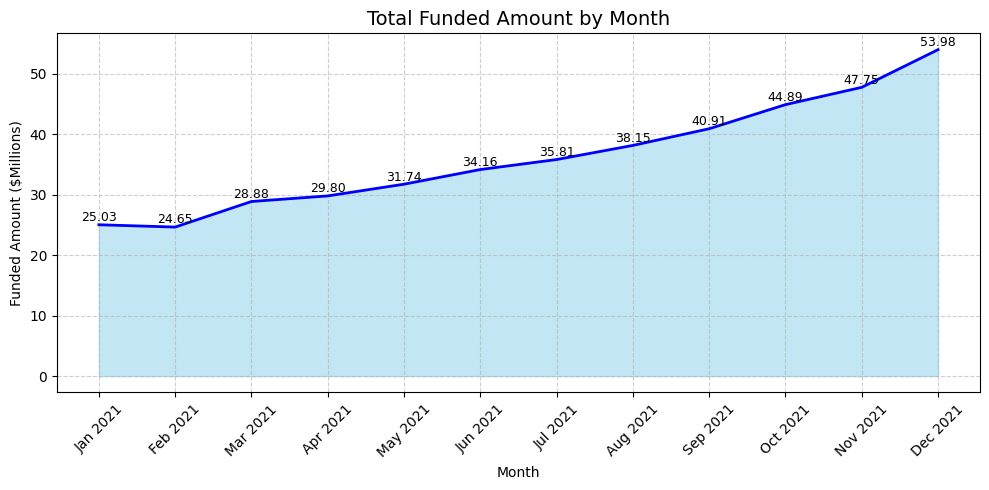

In [81]:
plt.figure(figsize=(10,5))
plt.fill_between(monthly_funded['month_name'],monthly_funded['loan_amount_millions'], color = 'skyblue', alpha=0.5)
plt.plot(monthly_funded['month_name'],monthly_funded['loan_amount_millions'], color = 'blue',linewidth=2)
for i, row in monthly_funded.iterrows():
     plt.text(i, row['loan_amount_millions']+0.1, f"{row['loan_amount_millions']:.2f}", ha='center' , va='bottom', fontsize=9, rotation=0, color='black')

plt.title('Total Funded Amount by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Funded Amount ($Millions)')
plt.xticks(ticks=range(len(monthly_funded)), labels=monthly_funded['month_name'], rotation =45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Monthly Trends by Issue Date  for Total Amount Received


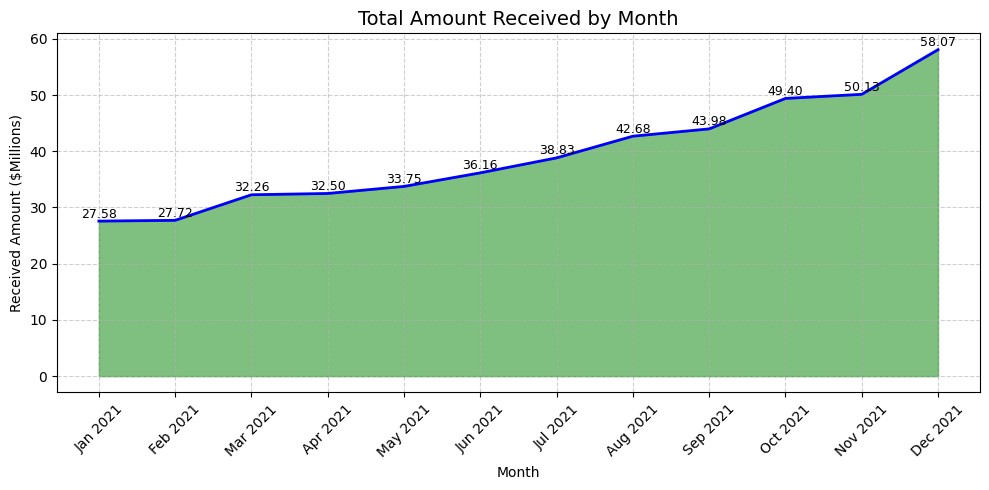

In [85]:
monthly_received = ( df.sort_values('issue_date').assign(month_name=lambda x: x['issue_date'].dt.strftime('%b %Y'))
                   .groupby('month_name', sort=False)['total_payment'].sum().div(1000000).reset_index(name='total_payment_millions'))
monthly_received.head()
plt.figure(figsize=(10,5))
plt.fill_between(monthly_received['month_name'],monthly_received['total_payment_millions'], color = 'green', alpha=0.5)
plt.plot(monthly_received['month_name'],monthly_received['total_payment_millions'], color = 'blue',linewidth=2)
for i, row in monthly_received.iterrows():
     plt.text(i, row['total_payment_millions']+0.1, f"{row['total_payment_millions']:.2f}", ha='center' , va='bottom', fontsize=9, rotation=0, color='black')

plt.title('Total Amount Received by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Received Amount ($Millions)')
plt.xticks(ticks=range(len(monthly_received)), labels=monthly_received['month_name'], rotation =45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Loan Applications By Issue Date

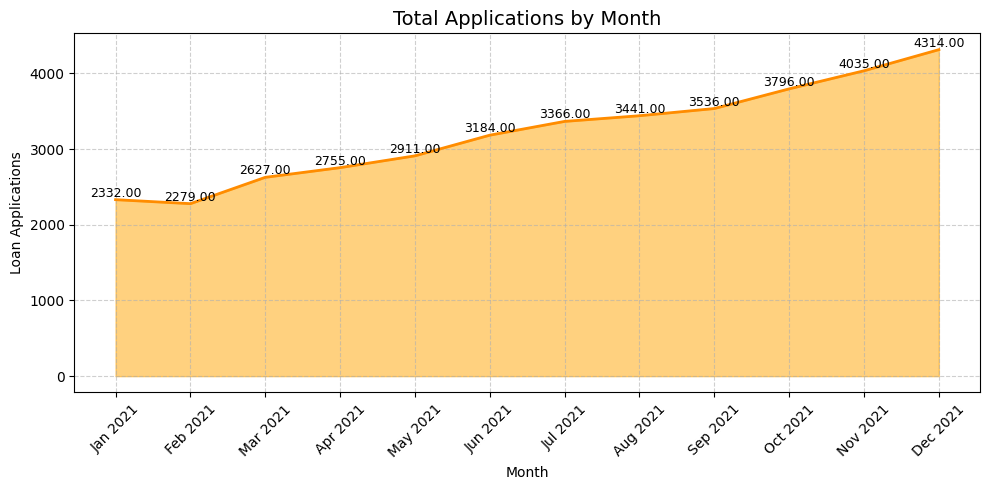

In [88]:
monthly_applications= ( df.sort_values('issue_date').assign(month_name=lambda x: x['issue_date'].dt.strftime('%b %Y'))
                   .groupby('month_name', sort=False)['id'].count().reset_index(name='total_applications'))
monthly_applications.head()
plt.figure(figsize=(10,5))
plt.fill_between(monthly_applications['month_name'],monthly_applications['total_applications'], color = 'orange', alpha=0.5)
plt.plot(monthly_applications['month_name'],monthly_applications['total_applications'], color = 'darkorange',linewidth=2)
for i, row in monthly_applications.iterrows():
     plt.text(i, row['total_applications']+0.1, f"{row['total_applications']:.2f}", ha='center' , va='bottom', fontsize=9, rotation=0, color='black')

plt.title('Total Applications by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Loan Applications')
plt.xticks(ticks=range(len(monthly_applications)), labels=monthly_applications['month_name'], rotation =45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## State Wise Total Funded amount


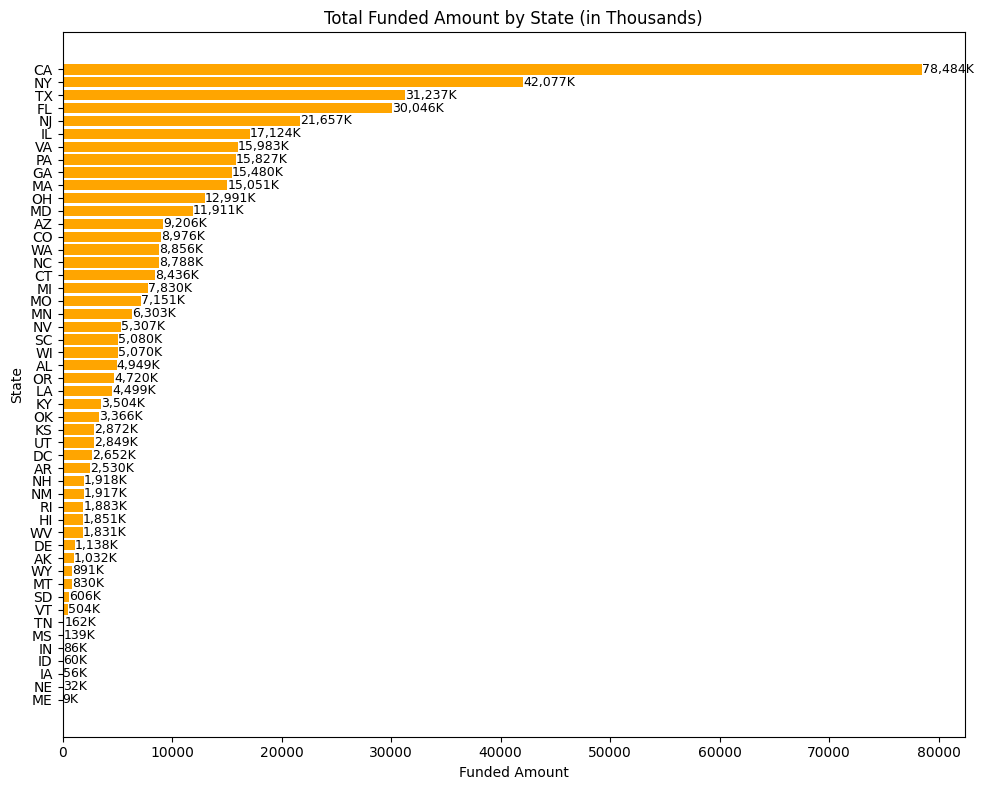

In [92]:
state_funding = df.groupby('address_state')['loan_amount'].sum().sort_values(ascending=True)
state_funding_thousands = state_funding/1000

plt.figure(figsize=(10,8))
bars = plt.barh(state_funding_thousands.index, state_funding_thousands.values, color = 'orange')

for bar in bars :
    width = bar.get_width()
    plt.text(width+10, bar.get_y()+bar.get_height()/2,
            f'{width:,.0f}K', va='center', fontsize=9)

plt.title('Total Funded Amount by State (in Thousands)')
plt.xlabel('Funded Amount')
plt.ylabel('State')
plt.tight_layout()
plt.show()





## Term Analysis by Total Funded Amount

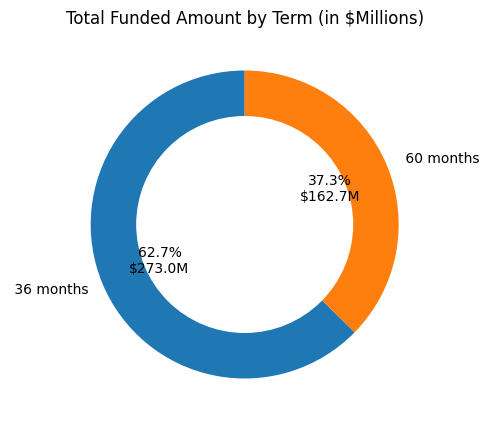

In [94]:
term_funding_millions = df.groupby('term')['loan_amount'].sum()/1000000

plt.figure(figsize=(5,5))
plt.pie(
    term_funding_millions,
    labels=term_funding_millions.index,
    autopct=lambda p: f"{p:.1f}%\n${p*sum(term_funding_millions)/100:.1f}M",
    startangle=90,
    wedgeprops={'width':0.4}
)
plt.gca().add_artist(plt.Circle((0,0),0.70,color='white'))
plt.title("Total Funded Amount by Term (in $Millions)")
plt.show()

## Employee Length by Total Funded Amount


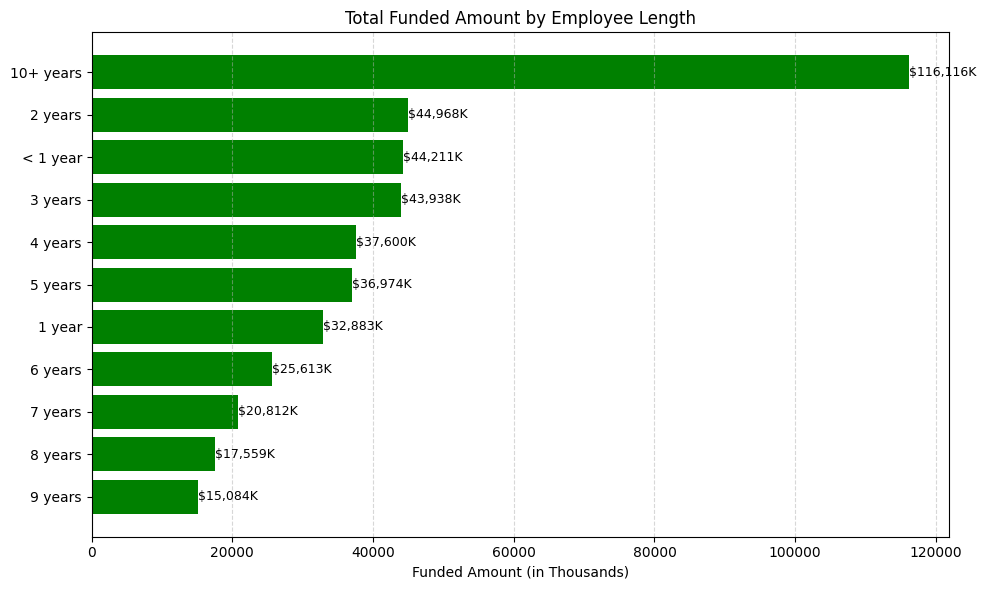

In [105]:
emp_length_funded = df.groupby('emp_length')['loan_amount'].sum().sort_values()
emp_length_funded_thousands = emp_length_funded/1000

plt.figure(figsize=(10,6))
bars = plt.barh(emp_length_funded_thousands.index,emp_length_funded_thousands.values, color="green")

for bar in bars :
     width = bar.get_width()
     plt.text(width + 10, bar.get_y()+bar.get_height()/2, f"${width:,.0f}K", va="center", fontsize=9)

plt.title("Total Funded Amount by Employee Length")
plt.xlabel("Funded Amount (in Thousands)")
plt.grid(axis="x", linestyle="--",alpha=0.5)
plt.tight_layout()
plt.show()



## Loan Purpose By Total Funded Amount

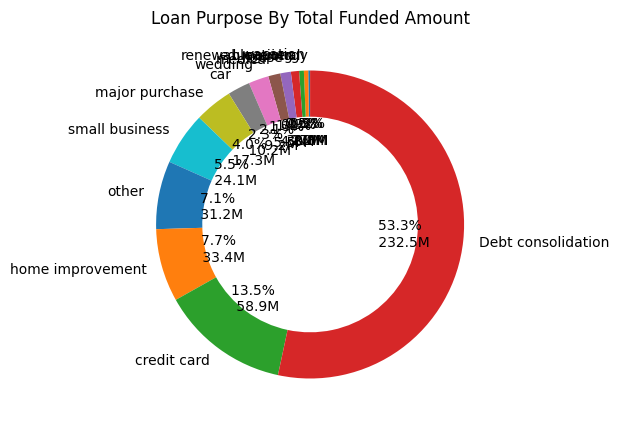

In [131]:
loan_purpose_amount_funded_millions = df.groupby('purpose')['loan_amount'].sum().sort_values()/1000000


plt.figure(figsize=(5,5))
plt.pie(loan_purpose_amount_funded_millions,
        labels=loan_purpose_amount_funded_millions.index,
        autopct = lambda p: f"{p:0.1f}% \n {p*sum(loan_purpose_amount_funded_millions)/100:.1f}M",
        startangle=90,
        wedgeprops={'width':0.3} 
       )
plt.title("Loan Purpose By Total Funded Amount")
plt.show()

## Home ownership By Total Funded Amount

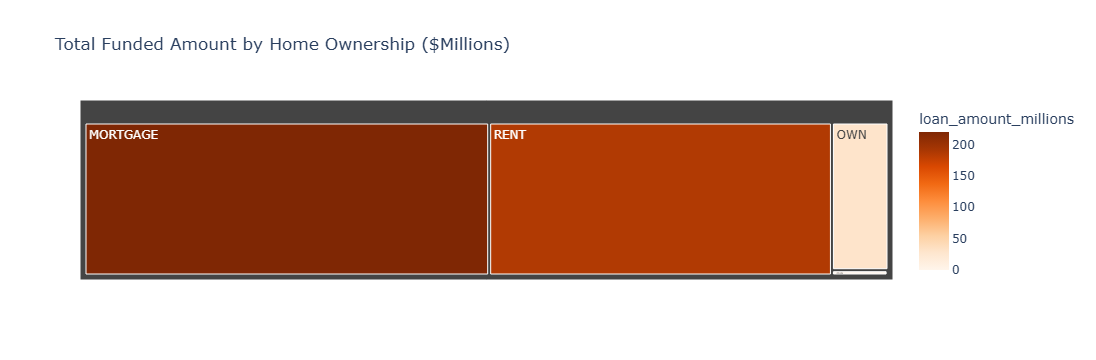

In [133]:
home_funding = df.groupby('home_ownership')['loan_amount'].sum().reset_index()
home_funding['loan_amount_millions'] = home_funding['loan_amount']/1000000

fig = px.treemap(
     home_funding,
     path=['home_ownership'],
     values='loan_amount_millions',
     color='loan_amount_millions',
     color_continuous_scale='oranges',
     title='Total Funded Amount by Home Ownership ($Millions)'
 )

fig.show()